In [ ]:
import networkx as nx
import numpy as np

```text
Linha 1:
N M S

N = Qtd Ilhas
M = Qtd Pontes
S = Qtd Sedes

Linhas Pontes:
A B P (M vezes)
A = Ilha A
B = Ilha B
P = Peso máximo entre elas

Linhas Sedes:
A B (S vezes)
A = Sede
B = Depósito
```

# <span style="color: #0446d6"> Execução para um único Grafo

## Leitura rodando no Google Colab

In [ ]:
from google.colab import files
arquivo = files.upload()

In [ ]:
#Leitura do .txt
texto = arquivo['Exemplo.txt'].decode('utf-8')

linhas = texto.splitlines() # Dividindo o texto em linhas

entrada = [] # Lista de entrada
for linha in linhas:
    elementos = linha.split() # Divide cada linha em um item
    elementos_int = [int(elem) for elem in elementos] # Converte os elementos para inteiro
    entrada.append(elementos_int) # Adiciona na lista

# Confirmação de leitura
for lista in entrada:
   print(lista)

## Leitura direta

In [63]:
with open("Exemplo.txt", "r", encoding="utf-8") as f:
    entrada = [
        list(map(int, linha.split()))
        for linha in f
        if linha.strip()
    ]

# Confirmação de leitura
for lista in entrada:
   print(lista)

[6, 7, 2]
[1, 2, 15]
[1, 3, 10]
[2, 3, 20]
[2, 4, 8]
[3, 5, 12]
[4, 6, 5]
[5, 6, 18]
[1, 4]
[3, 6]


## Mostrado o Grafo lido

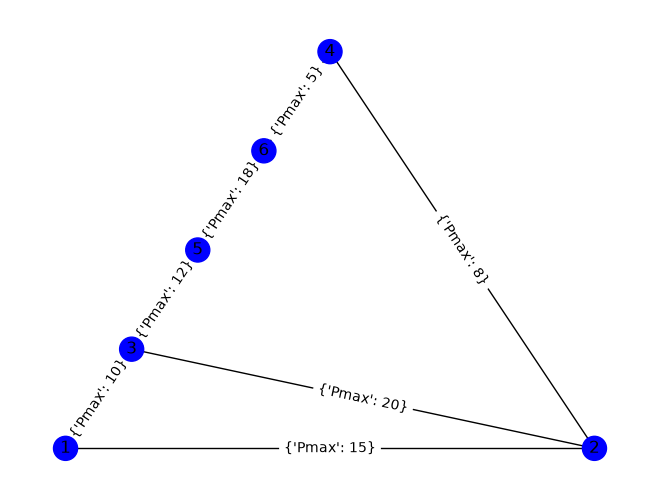

In [75]:
# Parte de plotagem do grafo inicial
entradas = entrada.copy()
G = nx.Graph()

qtdIlhas = entradas[0][0]
qtdPontes = entradas[0][1]
qtdSedes = entradas[0][2]
k = 0

#Adicionando as ilhas
for i in range(1, qtdIlhas):
  G.add_node(i)

entradas.remove(entradas[0]) # Apagando o primeiro conjunto que já foram salvos

#Inserindo as pontes com seus pesos
for i in range(qtdPontes):
   G.add_edge(entradas[i][0], entradas[i][1], Pmax = entradas[i][2])

# Já que já foram inseridos as pontes, apaga todas elas da lista de entradas
del entradas[:qtdPontes]

layout = nx.planar_layout(G)
cores = ['blue'] * len(G.nodes())  # Lista de cores dos nós inicialmente todos são azul


nx.draw(G, pos=layout, with_labels=True, node_color=cores)
nx.draw_networkx_edge_labels(G, pos=layout);

## Colorindo e mostrando os caminhos

Caminho: [1, 2, 4] Peso máximo: 8
Caminho: [3, 5, 6] Peso máximo: 12


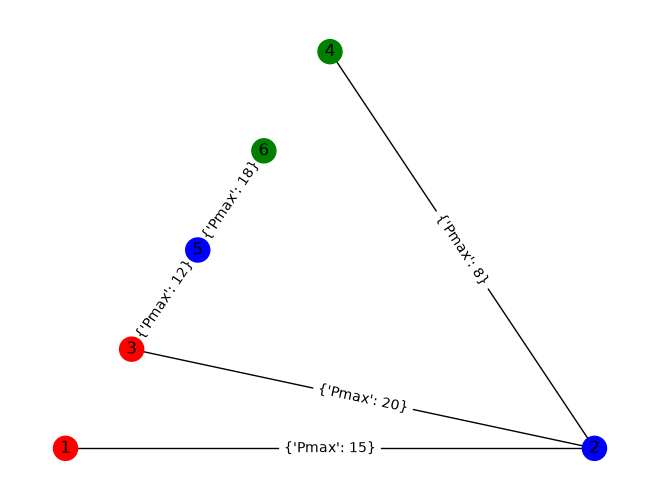

In [76]:
labels = nx.get_edge_attributes(G, 'Pmax') # Variável labels que receberá  um dicionário com o peso de cada conexão

# Reducto
while(list(nx.simple_cycles(G)) != []): # Enquanto não acabar com todos os ciclos
  allCycles = list(nx.simple_cycles(G)) # Faz uma lista com todos os ciclos
  allCycles = sorted(allCycles, key = len, reverse=True) # Deixa o maior elemento em primeiro
  peso = 9999 # Peso superável
  for i in range(len(allCycles[0])):
    if(allCycles[0][i] == allCycles[0][-1]): # Vê se o elemento atual é igual ao último
      x = allCycles[0][i] # Teórico último termo
      y = allCycles[0][0] # Com o primeiro
      pesoAtual = labels.get((x,y), labels.get((y,x)))
    else:
      x = allCycles[0][i] # Termo atual
      y = allCycles[0][i+1] # Com o seguinte
      pesoAtual = labels.get((x,y), labels.get((y,x)))
    if pesoAtual < peso:
      x1 = x
      y1 = y
      peso = pesoAtual
  G.remove_edge(x1,y1)
  allCycles.pop()
 # Inserindo as sedes e os destinos
for i in range(qtdSedes):
  cores[(entradas[i][0])-1] = 'red'
  cores[(entradas[i][1])-1] = 'green'
  caminho = nx.shortest_path(G, source = entradas[i][0], target = entradas[i][1]) # Acha o menor caminho entre o Source e o Target (Sede e destinos)
  peso = 9999 # Inicializado com um peso superável
  for j in range(len(caminho)-1): # Loop que irá, através do menor caminho, encontrar o maior peso possível
    pesoAtual = labels.get((caminho[j],caminho[j+1]), labels.get((caminho[j+1],caminho[j])))
    if peso > pesoAtual:
      peso = pesoAtual
  print("Caminho:", caminho, "Peso máximo:", peso)
del entradas[:qtdSedes]
nx.draw(G, pos=layout, with_labels=True, node_color=cores)
nx.draw_networkx_edge_labels(G, pos=layout);

## Execução completa

Caminho: [1, 2, 4] Peso máximo: 8
Caminho: [3, 5, 6] Peso máximo: 12




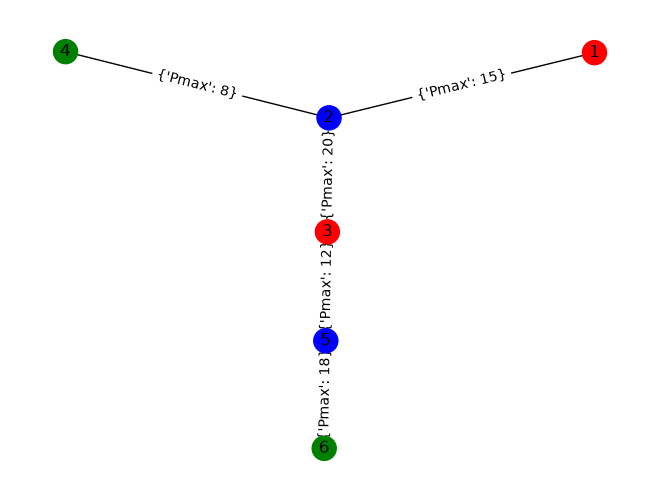

In [74]:
entradas = entrada.copy()
G = nx.Graph()
qtdIlhas=0

while entradas != []: # Enquanto ele não terminar de fazer todas as entradas
  qtdIlhasAnt = qtdIlhas
  qtdIlhas = entradas[0][0]
  qtdPontes = entradas[0][1]
  qtdSedes = entradas[0][2]
  k = 0

  #Adicionando as ilhas
  for i in range(1, qtdIlhas):
    G.add_node(i)

  entradas.remove(entradas[0]) # Apagando o primeiro conjunto que já foram salvos

  #Inserindo as pontes com seus pesos
  for i in range(qtdPontes):
    G.add_edge(entradas[i][0], entradas[i][1], Pmax = entradas[i][2])

  # Já que já foram inseridos as pontes, apaga todas elas da lista de entradas
  del entradas[:qtdPontes]

  cores = ['blue'] * len(G.nodes())  # Lista de cores dos nós inicialmente todos são azul

  labels = nx.get_edge_attributes(G, 'Pmax') # Variável labels que receberá  um dicionário com o peso de cada conexão

  # Reducto
  while(list(nx.simple_cycles(G)) != []): # Enquanto não acabar com todos os ciclos
    allCycles = list(nx.simple_cycles(G)) # Faz uma lista com todos os ciclos
    allCycles = sorted(allCycles, key = len, reverse=True) # Deixa o maior elemento em primeiro
    peso = 9999 # Peso superável
    for i in range(len(allCycles[0])):
      if(allCycles[0][i] == allCycles[0][-1]): # Vê se o elemento atual é igual ao último
        x = allCycles[0][i] # Teórico último termo
        y = allCycles[0][0] # Com o primeiro
        pesoAtual = labels.get((x,y), labels.get((y,x)))
      else:
        x = allCycles[0][i] # Termo atual
        y = allCycles[0][i+1] # Com o seguinte
        pesoAtual = labels.get((x,y), labels.get((y,x)))
      if pesoAtual < peso:
        x1 = x
        y1 = y
        peso = pesoAtual
    G.remove_edge(x1,y1)
    allCycles.pop()

  # Inserindo as sedes e os destinos
  for i in range(qtdSedes):
    cores[(entradas[i][0])-1] = 'red'
    cores[(entradas[i][1])-1] = 'green'
    caminho = nx.shortest_path(G, source = entradas[i][0], target = entradas[i][1]) # Acha o menor caminho entre o Source e o Target (Sede e destinos)
    peso = 9999 # Inicializado com um peso superável
    for j in range(len(caminho)-1): # Loop que irá, através do menor caminho, encontrar o maior peso possível
      pesoAtual = labels.get((caminho[j],caminho[j+1]), labels.get((caminho[j+1],caminho[j])))

      if peso > pesoAtual:
        peso = pesoAtual

    print("Caminho:", caminho, "Peso máximo:", peso)
  del entradas[:qtdSedes]
  print('\n')

# Verde = Destinos
# Vermelho = Sede
# Azul = Ilhas
layout = nx.kamada_kawai_layout(G)

nx.draw(G, pos=layout, with_labels=True, node_color=cores)
nx.draw_networkx_edge_labels(G, pos=layout);

# <span style="color: #0446d6"> Execução para Múltiplos Grafos

## Leitura rodando no Google Colab

In [78]:
from google.colab import files
arquivo = files.upload()

ModuleNotFoundError: No module named 'google'

In [ ]:
#Leitura do .txt
texto = arquivo['Exemplo.txt'].decode('utf-8')

linhas = texto.splitlines() # Dividindo o texto em linhas

entrada = [] # Lista de entrada
for linha in linhas:
    elementos = linha.split() # Divide cada linha em um item
    elementos_int = [int(elem) for elem in elementos] # Converte os elementos para inteiro
    entrada.append(elementos_int) # Adiciona na lista

# Confirmação de leitura
for lista in entrada:
   print(lista)

## Leitura direta

In [108]:
with open("Exemplo 2.txt", "r", encoding="utf-8") as f:
    entrada = [
        list(map(int, linha.split()))
        for linha in f
        if linha.strip()
    ]

# Confirmação de leitura
for lista in entrada:
   print(lista)

[6, 7, 2]
[1, 2, 15]
[1, 3, 10]
[2, 3, 20]
[2, 4, 8]
[3, 5, 12]
[4, 6, 5]
[5, 6, 18]
[1, 4]
[3, 6]
[6, 7, 2]
[1, 2, 25]
[1, 4, 30]
[2, 3, 18]
[2, 5, 12]
[3, 6, 10]
[4, 5, 22]
[5, 6, 16]
[2, 6]
[1, 5]
[6, 7, 2]
[1, 2, 8]
[1, 6, 20]
[2, 3, 14]
[3, 4, 11]
[4, 5, 9]
[5, 6, 13]
[2, 5, 17]
[1, 3]
[4, 6]


## Execução completa

Caminho: [1, 2, 4] Peso máximo: 8
Caminho: [3, 5, 6] Peso máximo: 12


Caminho: [8, 7, 10, 11, 12] Peso máximo: 16
Caminho: [7, 10, 11] Peso máximo: 22


Caminho: [13, 18, 17, 14, 15] Peso máximo: 13
Caminho: [16, 15, 14, 17, 18] Peso máximo: 11




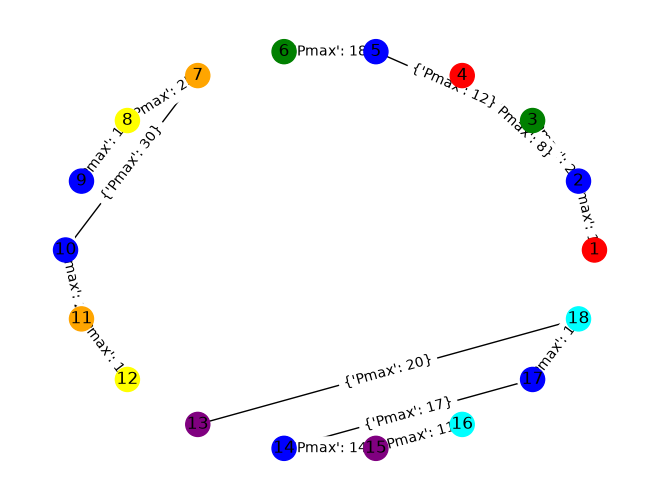

In [114]:
entradas = entrada.copy()

def pinta(cores, n1, n2, npode):
    colors = ['red', 'green', 'yellow', 'orange', 'purple', 'cyan', 'magenta']

    # Verifica cada cor na lista de cores permitidas
    for cor in colors:
        if cor not in npode:  # Verifica se a cor não está na lista de cores proibidas
            cores[n1] = cor
            cores[n2] = cor
            return cores  # Retorna a lista de cores se encontrar uma cor adequada

    # Se não encontrar uma cor adequada na lista de cores permitidas, retorna a lista original
    return cores

# Calculando a qtd de cores de forma dinâmica
total = 0
i = 0

while i < len(entradas):
    n, m, s = entradas[i]
    total += n
    i += 1 + m + s

cores = ['blue'] * total # Lista de cores dos nós inicialmente todos são azul
jafoi = []
G = nx.Graph()
qtdIlhas = 0
ant = 0
while entradas != []: # Enquanto ele não terminar de fazer todas as entradas
  qtdIlhas = entradas[0][0]
  qtdPontes = entradas[0][1]
  qtdSedes = entradas[0][2]
  k = 0

  #Adicionando as ilhas
  for i in range(1, qtdIlhas):
    G.add_node(i+ant)

  entradas.remove(entradas[0]) # Apagando o primeiro conjunto que já foram salvos

  #Inserindo as pontes com seus pesos
  for i in range(qtdPontes):
    G.add_edge((entradas[i][0]+ant), (entradas[i][1]+ant), Pmax = entradas[i][2])

  # Já que já foram inseridos as pontes, apaga todas elas da lista de entradas
  del entradas[:qtdPontes]

  labels = nx.get_edge_attributes(G, 'Pmax') # Variável labels que receberá  um dicionário com o peso de cada conexão

  # Reducto
  while(list(nx.simple_cycles(G)) != []): # Enquanto não acabar com todos os ciclos
    allCycles = list(nx.simple_cycles(G)) # Faz uma lista com todos os ciclos
    allCycles = sorted(allCycles, key = len, reverse=True) # Deixa o maior elemento em primeiro
    peso = 9999 # Peso superável
    for i in range(len(allCycles[0])):
      if(allCycles[0][i] == allCycles[0][-1]): # Vê se o elemento atual é igual ao último
        x = allCycles[0][i] # Teórico último termo
        y = allCycles[0][0] # Com o primeiro
        pesoAtual = labels.get((x,y), labels.get((y,x)))
      else:
        x = allCycles[0][i] # Termo atual
        y = allCycles[0][i+1] # Com o seguinte
        pesoAtual = labels.get((x,y), labels.get((y,x)))
      if pesoAtual < peso:
        x1 = x
        y1 = y
        peso = pesoAtual
    G.remove_edge(x1,y1)
    allCycles.pop()

  # Inserindo as sedes e os destinos
  for i in range(qtdSedes):
    cores = pinta(cores, (entradas[i][0]-1+ant), (entradas[i][1]-1+ant), jafoi)
    jafoi.append(cores[(entradas[i][0]-1+ant)])
    #cores[(entradas[i][0])-1+ant] = 'red'
    #cores[(entradas[i][1])-1+ant] = 'green'
    caminho = nx.shortest_path(G, source = entradas[i][0]+ ant, target = entradas[i][1]+ ant) # Acha o menor caminho entre o Source e o Target (Sede e destinos)
    peso = 9999 # Inicializado com um peso superável
    for j in range(len(caminho)-1): # Loop que irá, através do menor caminho, encontrar o maior peso possível
      pesoAtual = labels.get((caminho[j],caminho[j+1]), labels.get((caminho[j+1],caminho[j])))

      if peso > pesoAtual:
        peso = pesoAtual

    print("Caminho:", caminho, "Peso máximo:", peso)
  ant += qtdIlhas
  del entradas[:qtdSedes]
  print('\n')

layout = nx.kamada_kawai_layout(G)
layout = nx.circular_layout(G)
nx.draw(G, pos=layout, with_labels=True, node_color=cores)
nx.draw_networkx_edge_labels(G, pos=layout);